# 01 Exploratory Data Analysis (EDA)

01 Exploratory Data Analysis (EDA)

El objetivo de este notebook es explorar el dataset de clientes, evaluar su calidad e identificar patrones asociados con la variable objetivo `Churn`.

El análisis se centrará en:

- revisar la estructura y calidad de los datos;
- estudiar la distribución de las variables;
- analizar el desbalance de la variable objetivo;
- explorar la relación entre las características de los clientes y el churn;
- identificar aspectos relevantes para el posterior preprocesamiento y modelado.

Las relaciones identificadas durante el EDA se interpretarán como asociaciones y no como relaciones causales.


1. Imports y carga de datos
2. Inspección inicial y calidad de datos
3. Preparación de los datos para el EDA
4. Análisis univariante
5. Análisis bivariante respecto a Churn
6. Correlación entre variables numéricas
7. Conclusiones del EDA

## 1. Imports y carga de datos

Se importan las librerías necesarias para el análisis y se carga el dataset original.

In [59]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

CSV_PATH = Path("../data/raw/Telco-Customer-Churn.csv")

df_raw = pd.read_csv(CSV_PATH)

df_raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Inspección inicial y calidad de datos

Antes de realizar transformaciones, se analiza la estructura del dataset y se buscan posibles problemas de calidad.

### 2.1 Dimensiones y tipos

In [60]:
print("Dimensiones del dataset:", df_raw.shape)
df_raw.info()

Dimensiones del dataset: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling 

El dataset contiene 7.043 observaciones y 21 variables. A primera vista, Pandas no detecta valores nulos (`NaN`) en ninguna de las columnas.

Sin embargo, se observa una posible inconsistencia en los tipos de datos: `TotalCharges`, que conceptualmente representa una cantidad monetaria, ha sido interpretada como texto.

Por tanto, es necesario analizar sus valores antes de continuar.

### 2.2 Análisis de `TotalCharges`

Se comprueba si `TotalCharges` contiene valores que impiden su conversión a formato numérico.

In [ ]:
total_charges_numeric = pd.to_numeric(df_raw["TotalCharges"], errors="coerce")

total_charges_numeric.isna().sum()

np.int64(11)

In [ ]:
# Mostramos las filas cuyos valores de TotalCharges no pueden convertirse a numérico

df_raw.loc[
    total_charges_numeric.isna(),
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"],
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [ ]:
df_raw.loc[total_charges_numeric.isna(), "TotalCharges"].unique()

<StringArray>
[' ']
Length: 1, dtype: str

Se identifican 11 registros cuyo valor de `TotalCharges` no puede convertirse a formato numérico. En todos ellos, el valor original corresponde a un espacio en blanco y los clientes presentan `tenure = 0`.

Dado que se trata de clientes sin antigüedad acumulada, durante la preparación de los datos estos valores se convertirán a `0`.

### 2.3 Duplicados e identificadores

In [64]:
df_raw.duplicated().sum()

np.int64(0)

In [65]:
df_raw["customerID"].nunique()

7043

In [66]:
df_raw["customerID"].duplicated().sum()

np.int64(0)

No se observan filas duplicadas y los 7.043 valores de `customerID` son únicos, por lo que cada fila representa un cliente diferente.

`customerID` se considera únicamente un identificador y no se utilizará posteriormente como variable predictora.

### 2.4 Valores de variables categóricas

Se inspeccionan las variables categoricas para ver que valores contienen cada una de ellas

In [ ]:
categorical_cols = df_raw.select_dtypes(include=["object", "string"]).columns

for col in categorical_cols:
    print(f"{col}: {df_raw[col].unique()}")

customerID: <StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str
gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection: <StringArray>
['No', 'Yes', 'No internet service']



Cuando un cliente no dispone de servicio de Internet, las prestaciones asociadas utilizan la categoría `No internet service`. De forma similar, `MultipleLines` puede tomar el valor `No phone service`.

Estas categorías representan situaciones reales del cliente y no valores ausentes, por lo que deberán conservarse y tratarse adecuadamente durante el preprocesamiento.

## 3. Preparación de los datos para el EDA

A partir de este punto se trabajará sobre una copia del dataset original. De esta forma, `df_raw` se mantiene sin modificaciones y `df` contiene las transformaciones necesarias para continuar el análisis.

### 3.1 Copia del dataset

In [68]:
df = df_raw.copy()

### 3.2 Conversión de `TotalCharges`

`TotalCharges` se convierte a formato numérico. Los 11 valores no convertibles identificados previamente se sustituyen por `0`, de acuerdo con el patrón observado en los clientes con `tenure = 0`.

Tras la transformación, `TotalCharges` queda disponible como variable numérica y no contiene valores ausentes.

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [70]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   tenure          7043 non-null   int64  
 1   MonthlyCharges  7043 non-null   float64
 2   TotalCharges    7043 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 165.2 KB


In [71]:
df["TotalCharges"].isna().sum()

np.int64(0)

## 4. Análisis univariante

### 4.1 Variable objetivo: `Churn`

In [72]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [73]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Aproximadamente el 26,5 % de los clientes presentan churn, frente al 73,5 % que permanecen.

Existe, por tanto, un desbalance moderado de clases. Este aspecto deberá tenerse en cuenta durante la evaluación de los modelos, ya que un clasificador que predijera siempre la clase mayoritaria alcanzaría aproximadamente un 73,5 % de accuracy sin identificar ningún cliente que abandona.

Por este motivo, la evaluación posterior no se basará únicamente en accuracy.

### 4.2 Variables categóricas

Aunque `SeniorCitizen` está almacenada numéricamente mediante los valores `0` y `1`, conceptualmente representa una característica binaria. Por este motivo se analizará junto con las variables categóricas.

In [75]:
categorical_cols_plot = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
]

/tmp/ipykernel_6362/1860553017.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels)


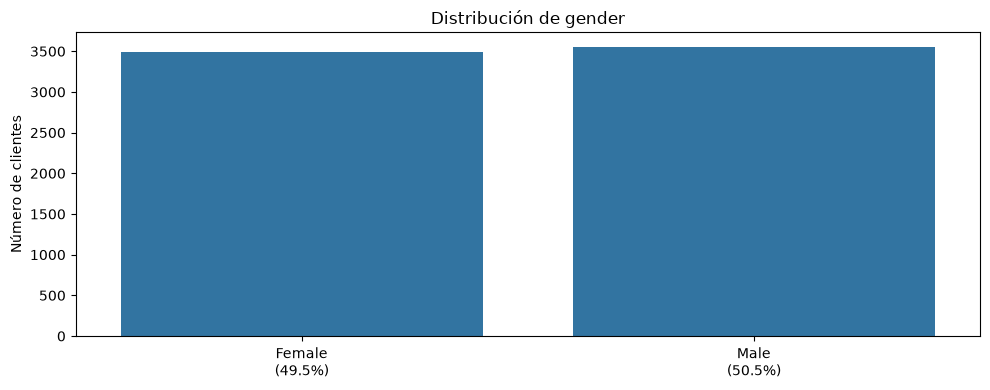

/tmp/ipykernel_6362/1860553017.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels)


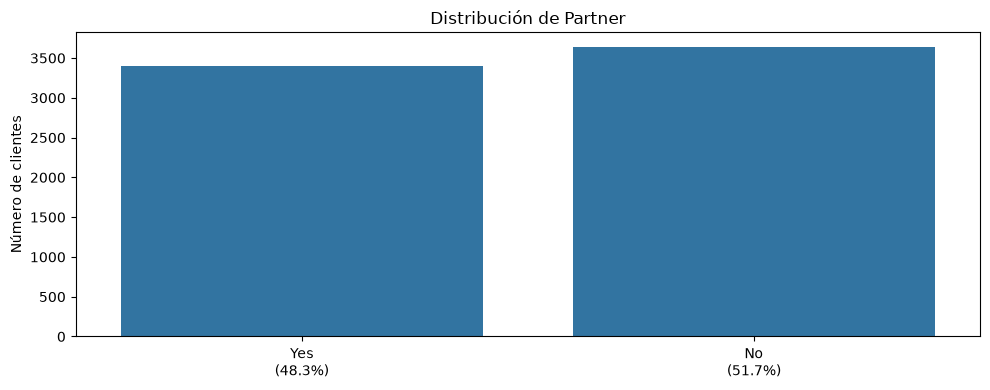

/tmp/ipykernel_6362/1860553017.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels)


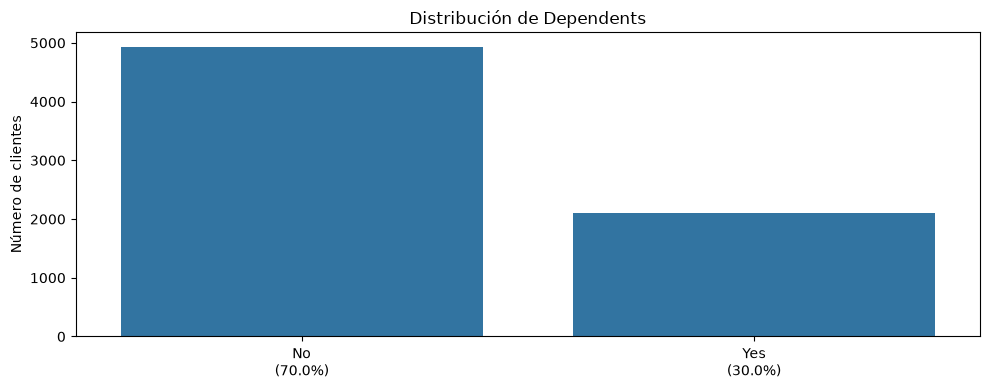

/tmp/ipykernel_6362/1860553017.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels)


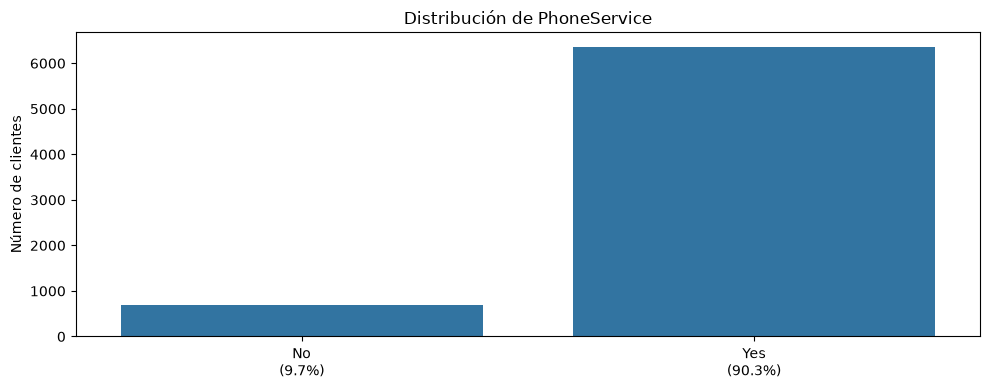

/tmp/ipykernel_6362/1860553017.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels)


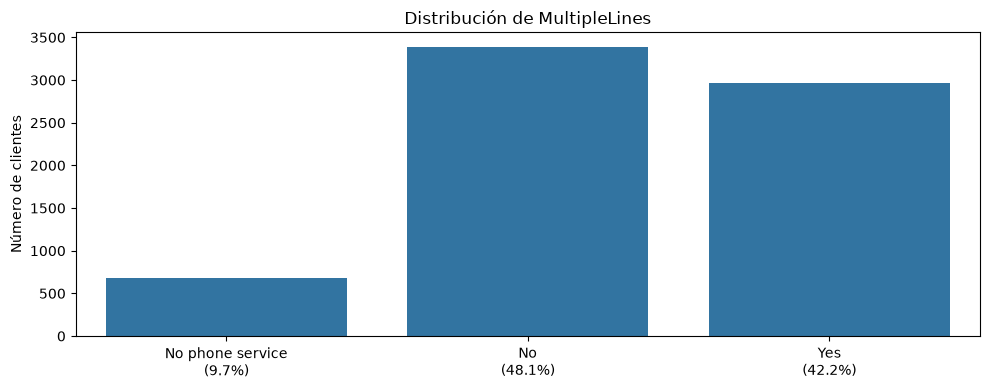

/tmp/ipykernel_6362/1860553017.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels)


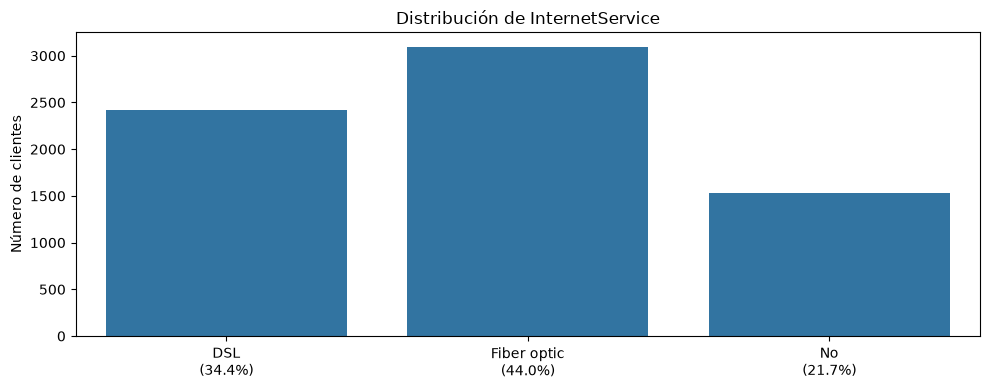

/tmp/ipykernel_6362/1860553017.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels)


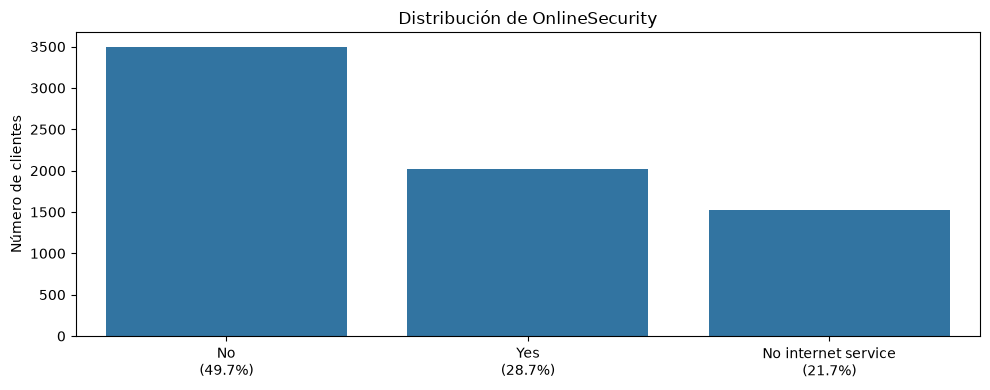

/tmp/ipykernel_6362/1860553017.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels)


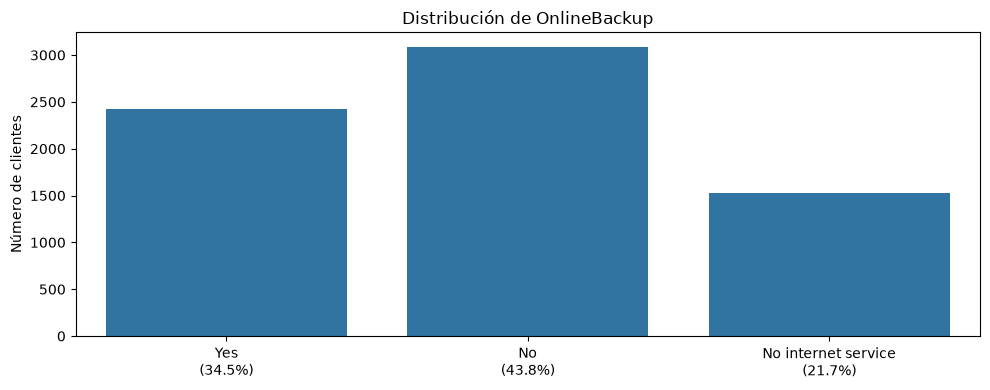

/tmp/ipykernel_6362/1860553017.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels)


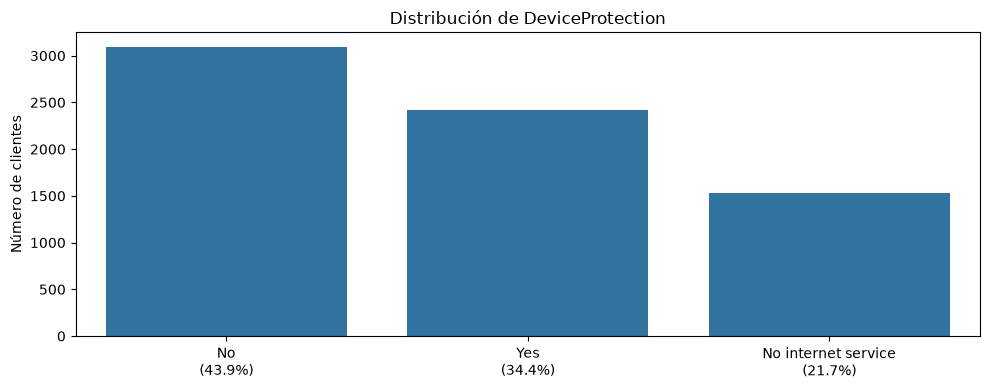

/tmp/ipykernel_6362/1860553017.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels)


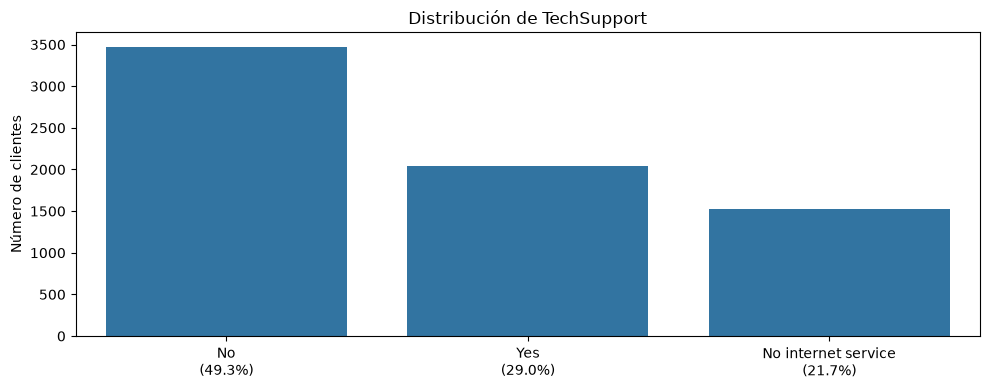

/tmp/ipykernel_6362/1860553017.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels)


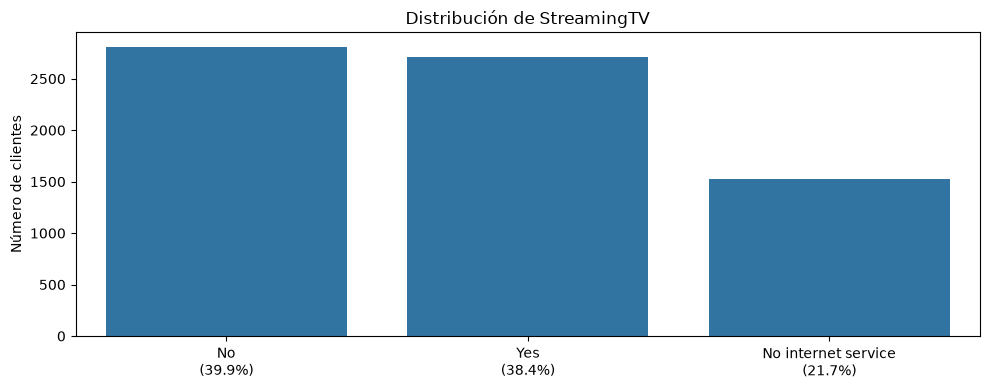

/tmp/ipykernel_6362/1860553017.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels)


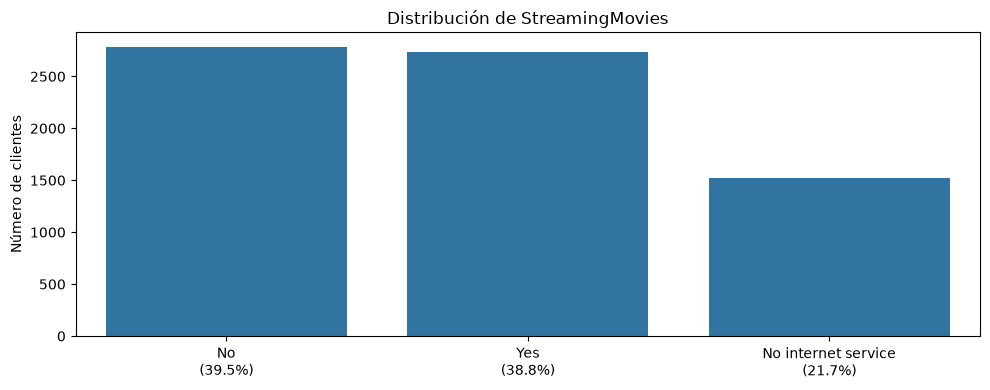

/tmp/ipykernel_6362/1860553017.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels)


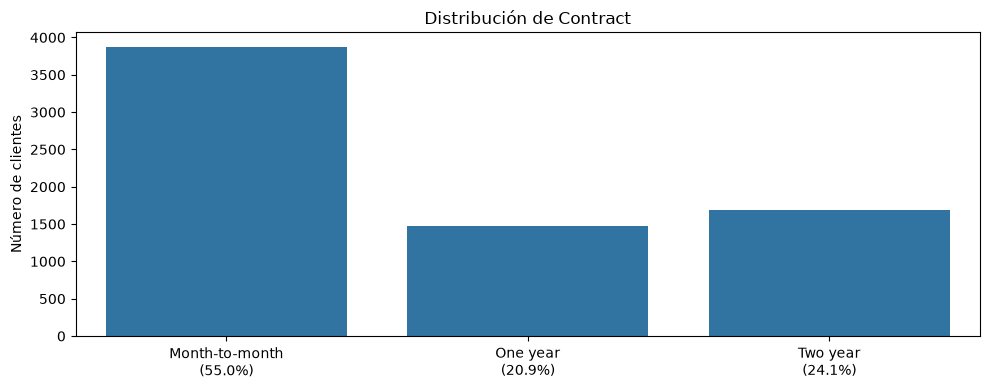

/tmp/ipykernel_6362/1860553017.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels)


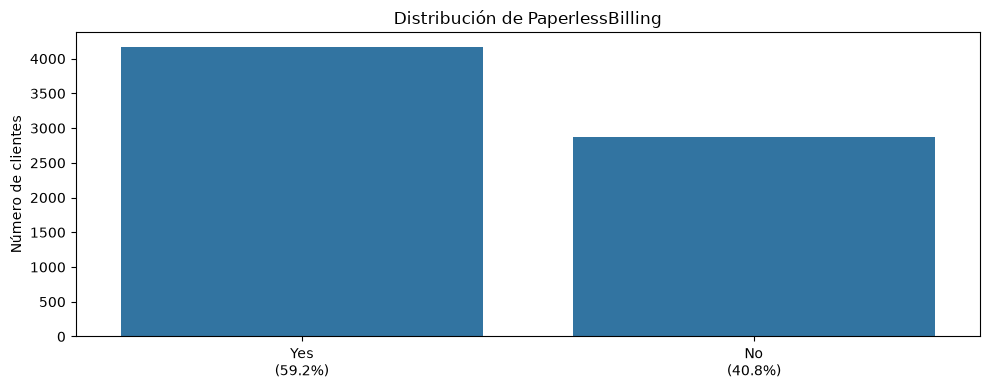

/tmp/ipykernel_6362/1860553017.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels)


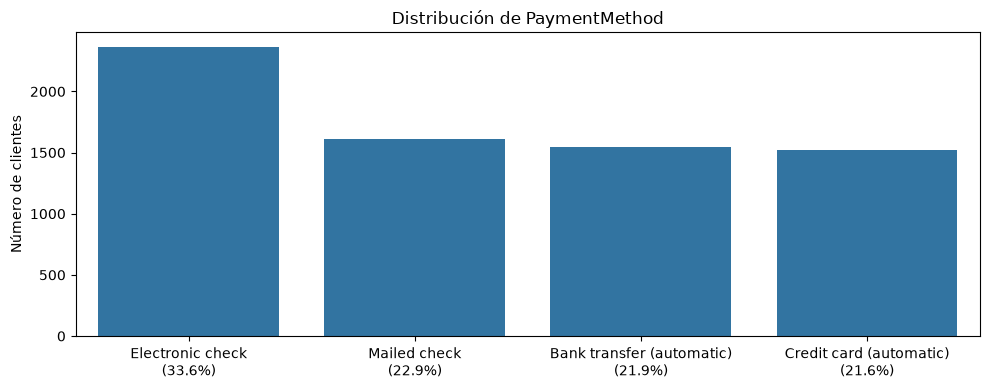

/tmp/ipykernel_6362/1860553017.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels)


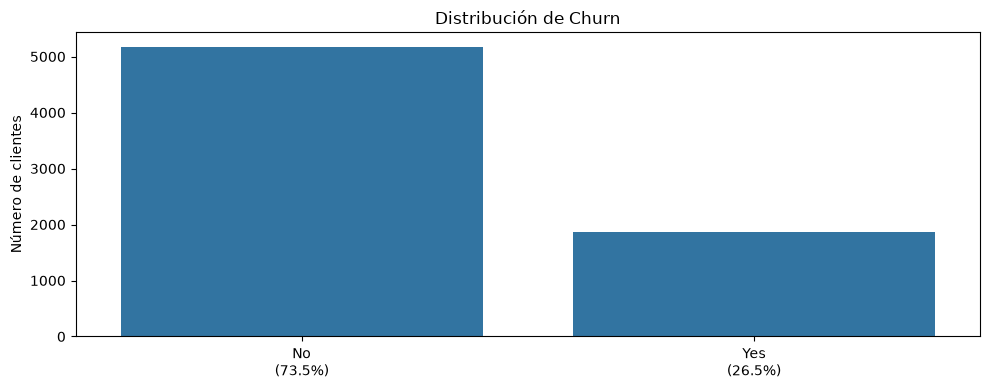

In [ ]:
for col in categorical_cols_plot:
    plt.figure(figsize=(10, 4))

    ax = sns.countplot(data=df_raw, x=col)

    percentages = df_raw[col].value_counts(normalize=True)

    labels = [
        f"{label.get_text()}\n({percentages[label.get_text()]:.1%})"
        for label in ax.get_xticklabels()
    ]

    ax.set_xticklabels(labels)

    plt.title(f"Distribución de {col}")
    plt.xlabel("")
    plt.ylabel("Número de clientes")
    plt.tight_layout()
    plt.show()

Las variables categóricas presentan distribuciones heterogéneas. Algunas características, como `gender`, se encuentran relativamente equilibradas, mientras que otras muestran una mayor concentración en determinadas categorías.

También se observan categorías como `No internet service` y `No phone service`, que reflejan la ausencia del servicio correspondiente y no valores perdidos. Esta estructura deberá conservarse durante el posterior preprocesamiento.

### 4.3. Variables numéricas

In [77]:
numeric_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
]

In [78]:
df[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


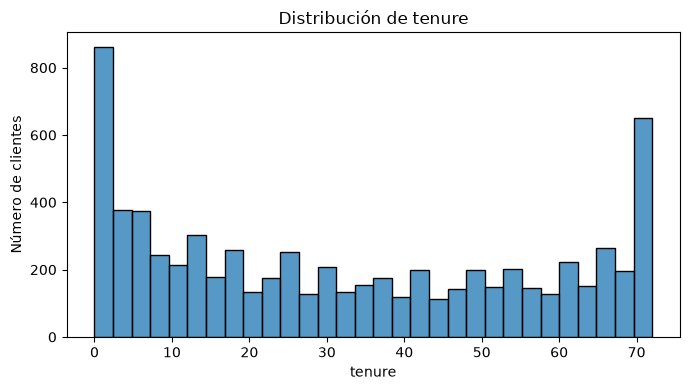

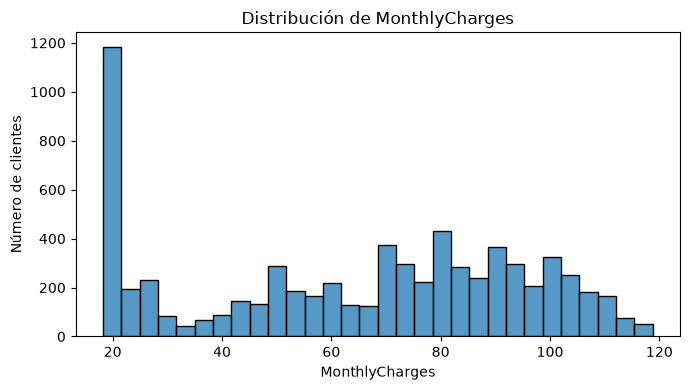

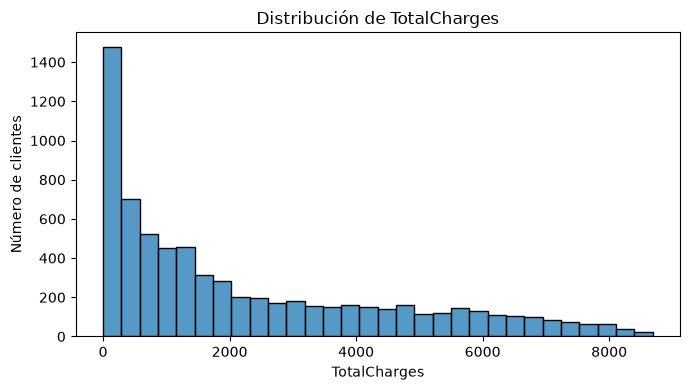

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))

    sns.histplot(data=df, x=col, bins=30)

    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Número de clientes")
    plt.tight_layout()
    plt.show()

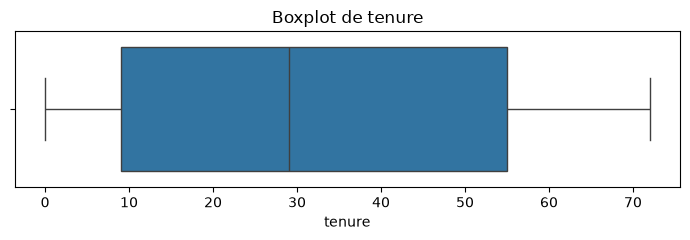

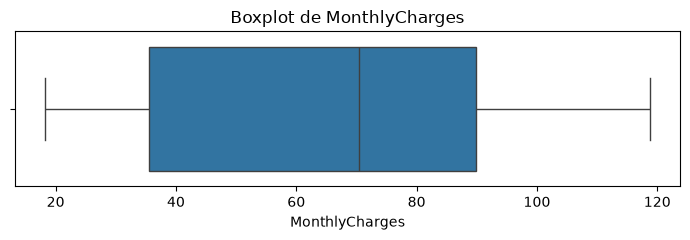

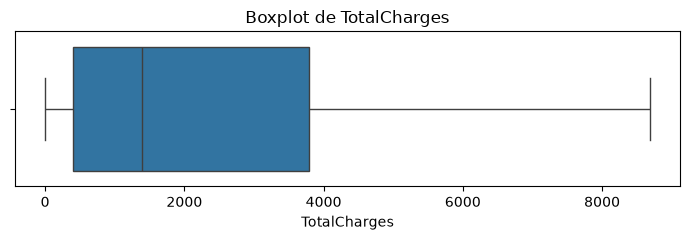

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(7, 2.5))

    sns.boxplot(data=df, x=col)

    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

Las variables numéricas presentan distribuciones diferentes. `tenure` muestra una elevada concentración de clientes con poca antigüedad y otra concentración próxima al máximo de 72 meses, mientras que `MonthlyCharges` presenta una concentración destacada en los valores más bajos y una distribución más dispersa en el resto del rango.

`TotalCharges` presenta una distribución asimétrica positiva, con mayor concentración en valores bajos y una cola hacia valores elevados. Este comportamiento es coherente con su naturaleza acumulativa y se analizará posteriormente junto con `tenure` y `MonthlyCharges`.

Los diagramas de caja no muestran valores anómalos evidentes que justifiquen eliminar observaciones en esta fase.

## 5. Análisis bivariante

### 5.1 Variables Categóricas vs Churn

In [ ]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [ ]:
def plot_churn_rate(data, column):
    """Muestra la tasa de churn para cada categoría de una variable."""

    churn_rate = (
        data.groupby(column)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(8, 6))

    ax = sns.barplot(x=churn_rate.index, y=churn_rate.values)

    ax.bar_label(ax.containers[0], fmt="%.1f%%")

    plt.title(f"Tasa de Churn por {column}")
    plt.xlabel(column)
    plt.ylabel("Tasa de Churn (%)")
    plt.xticks()
    plt.tight_layout()
    plt.show()

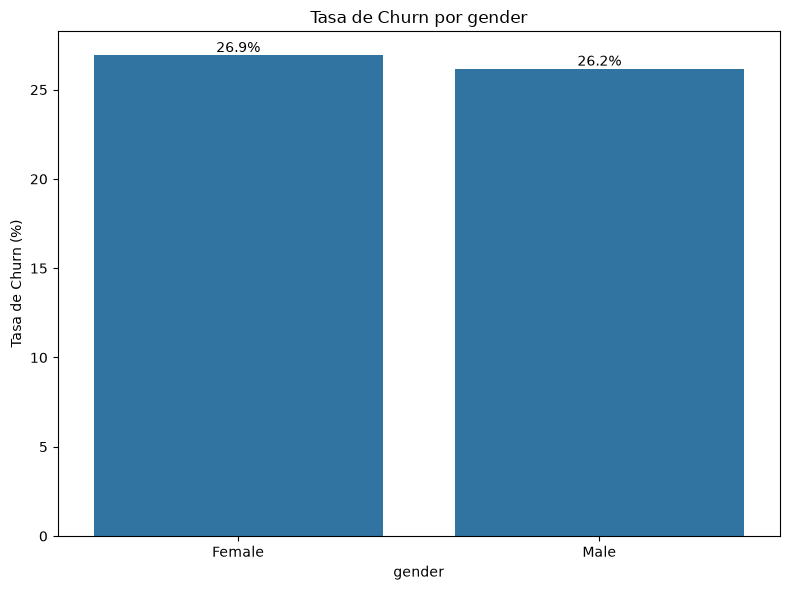

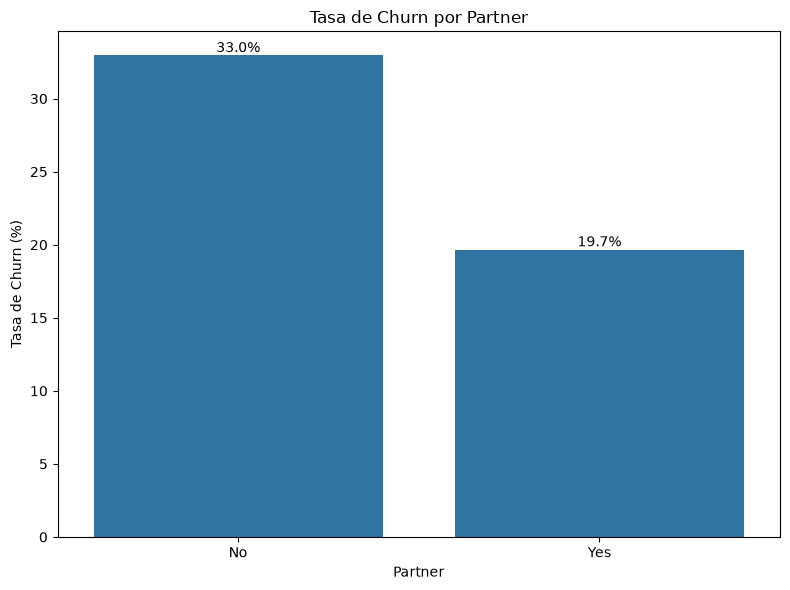

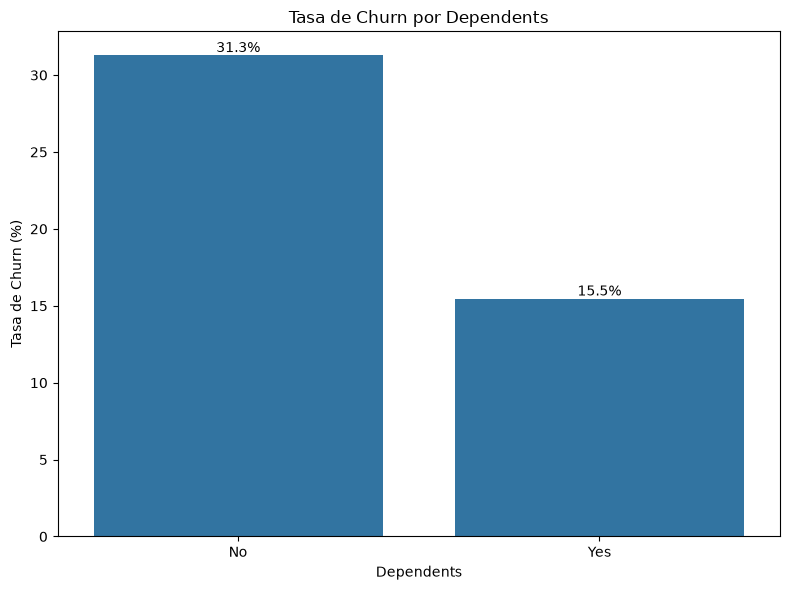

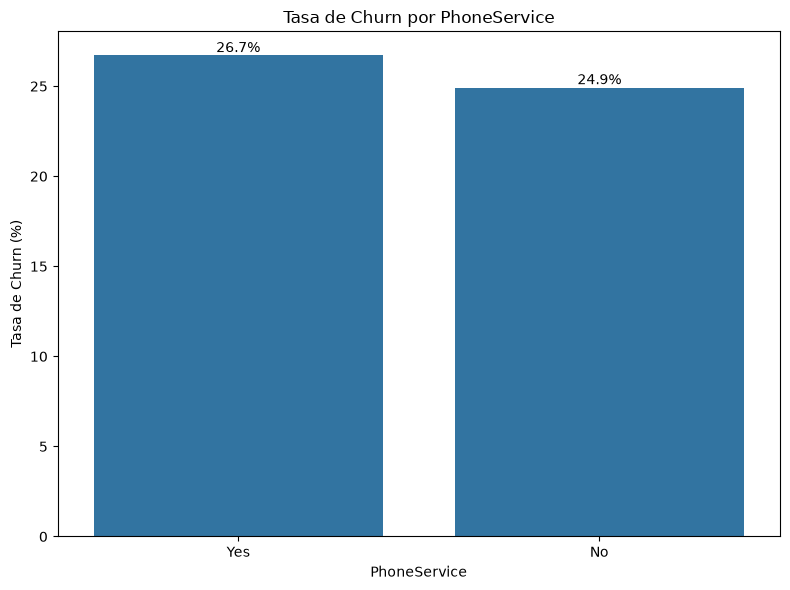

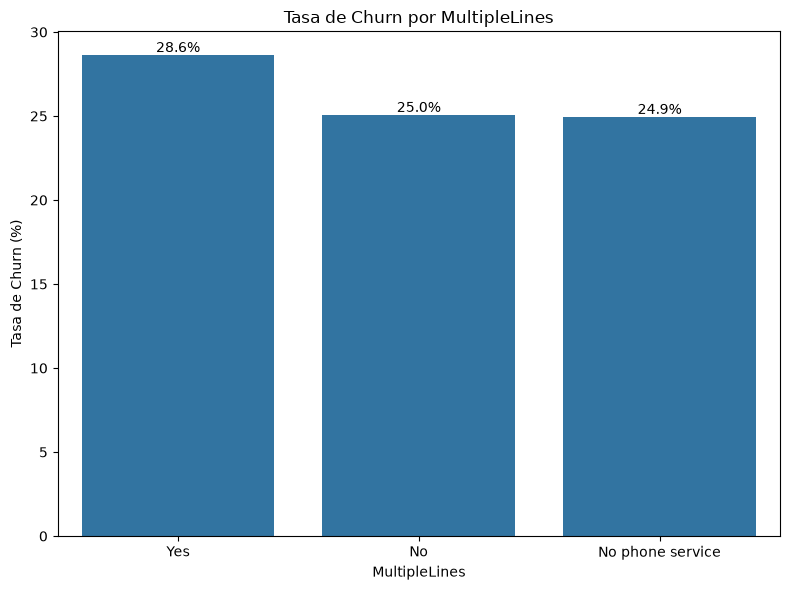

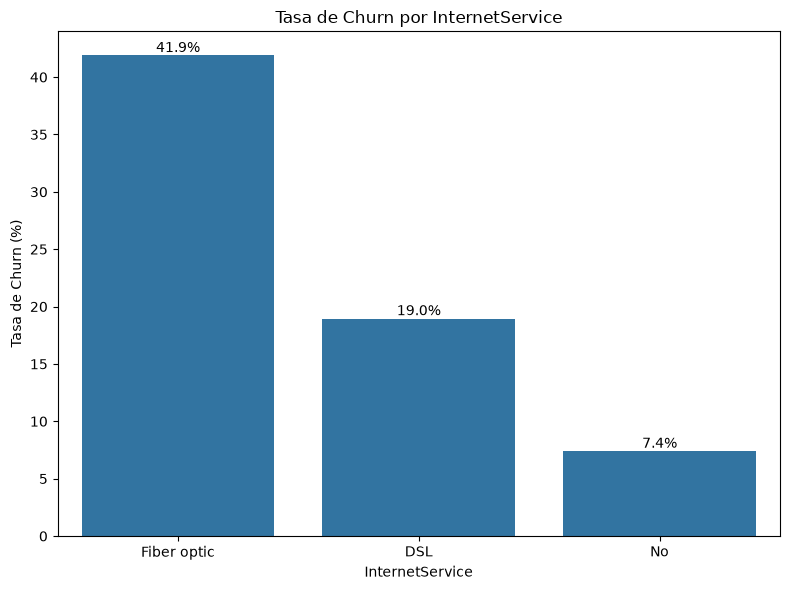

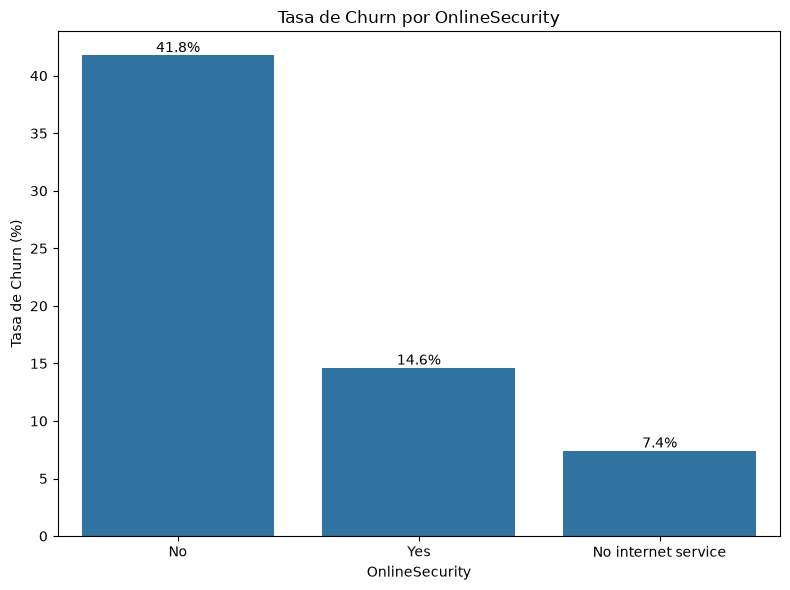

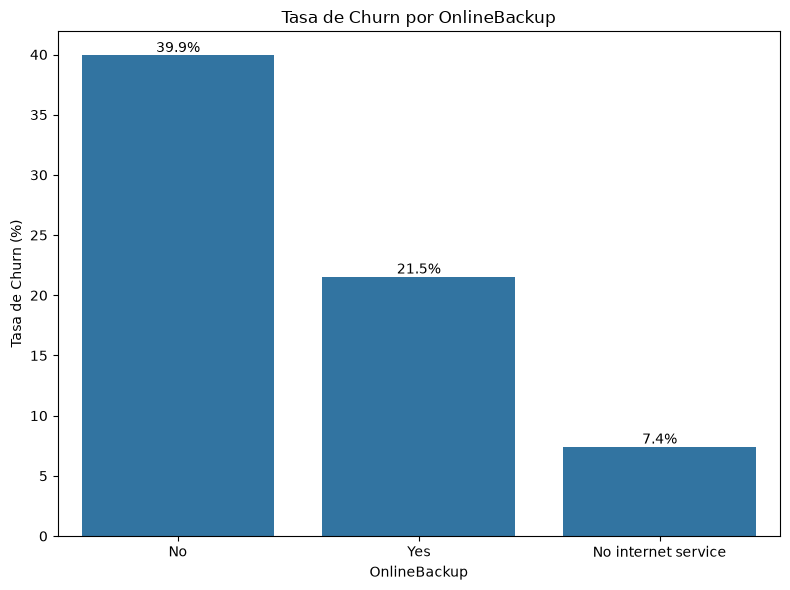

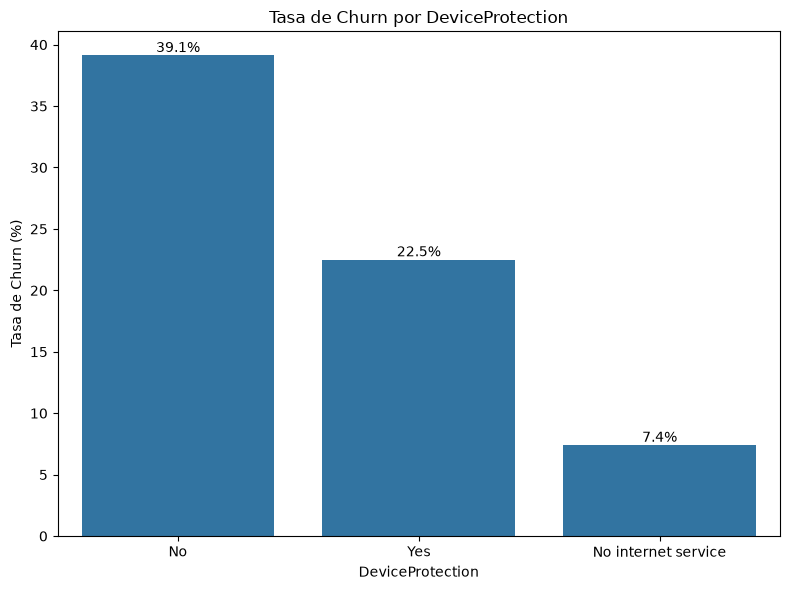

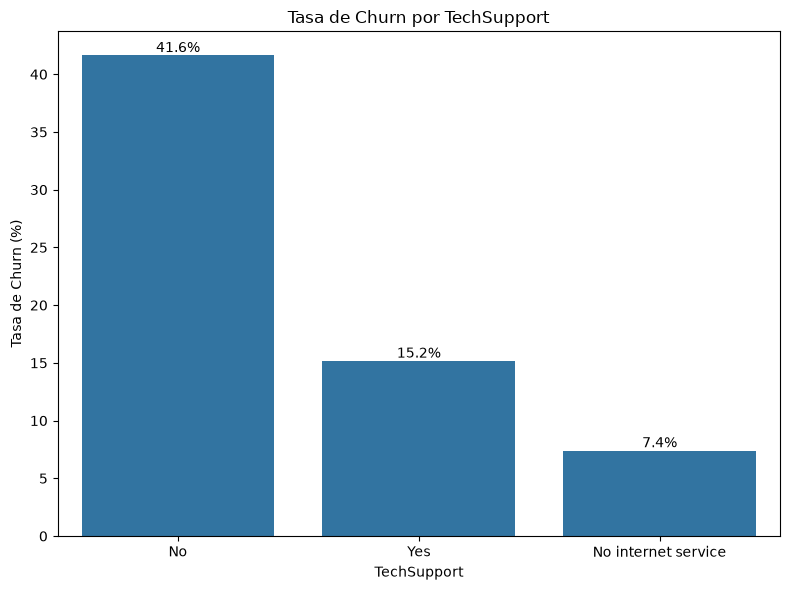

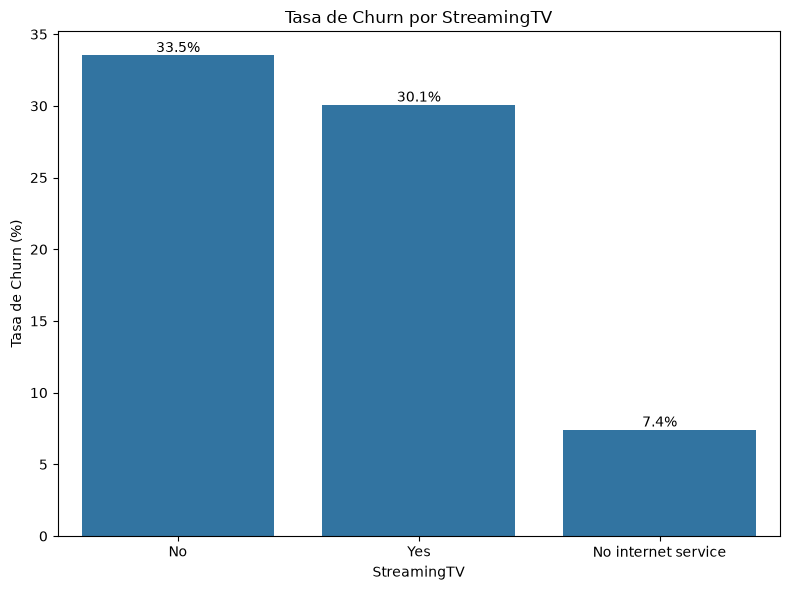

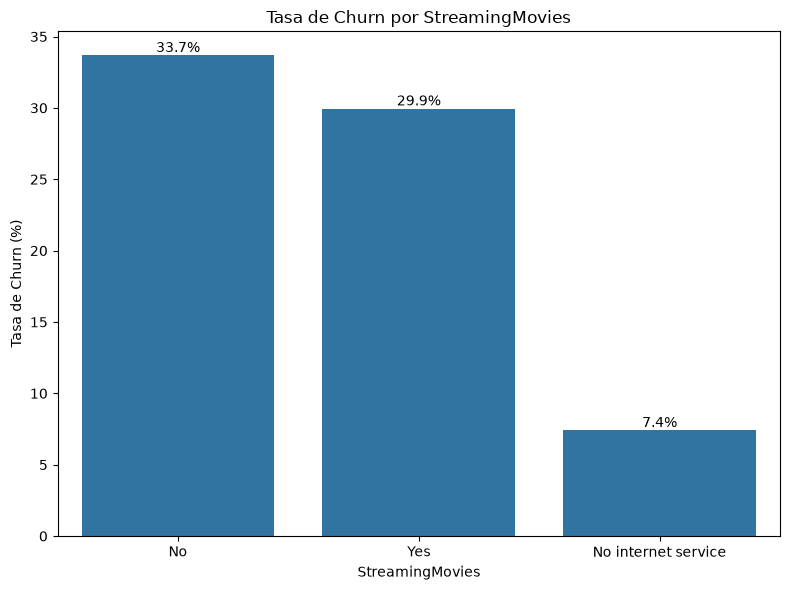

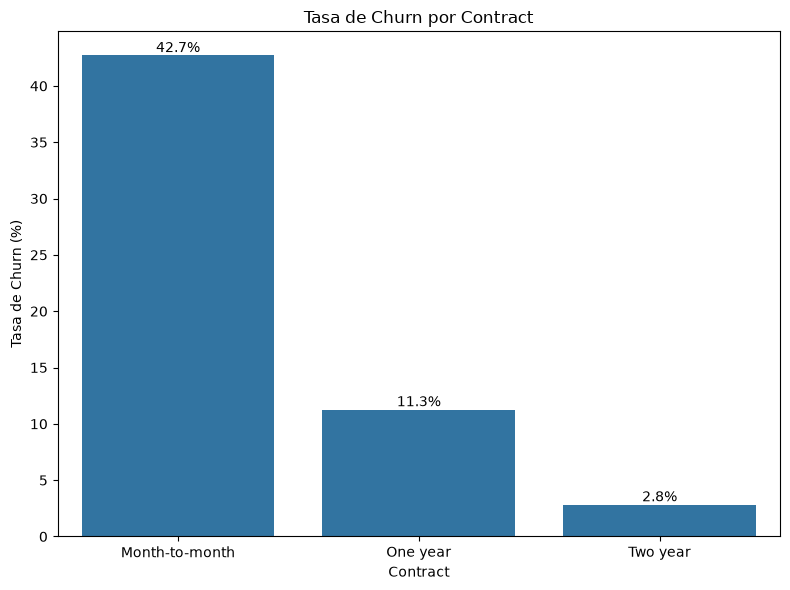

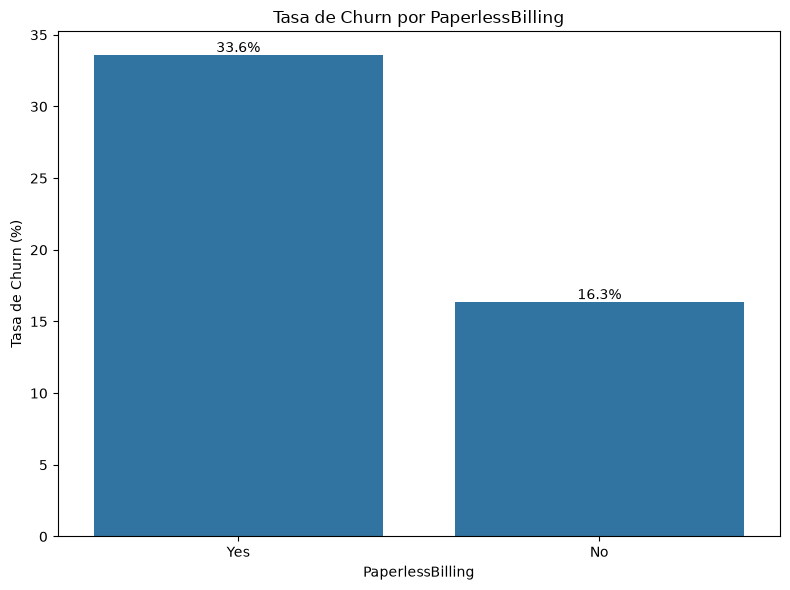

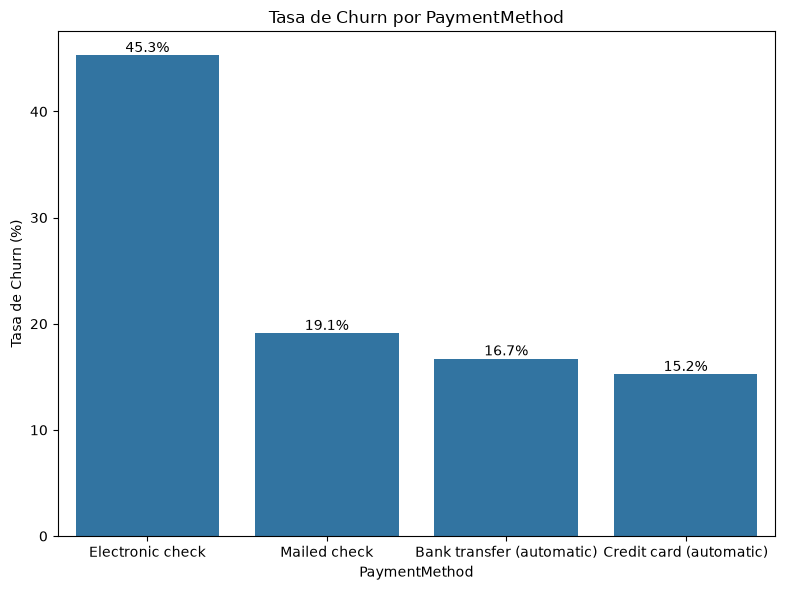

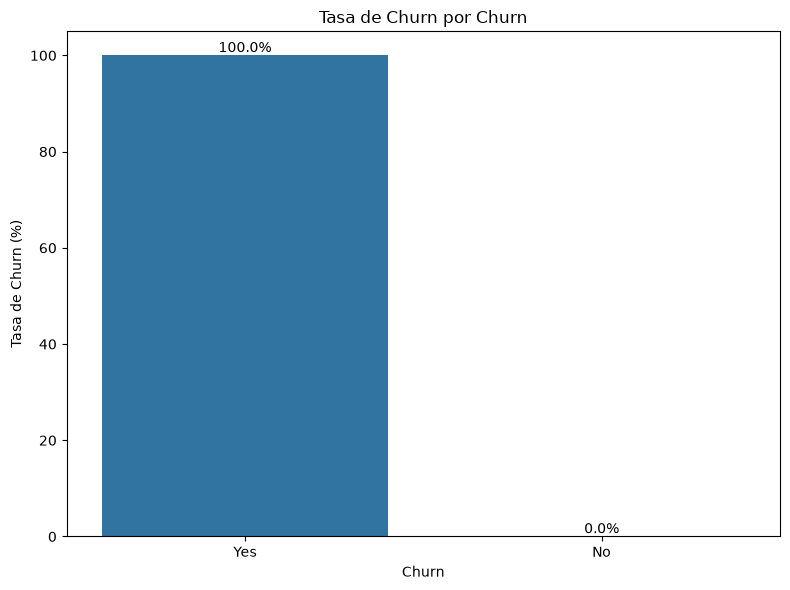

In [86]:
for col in categorical_cols_plot:
    plot_churn_rate(df, col)

El análisis muestra diferencias relevantes en la tasa de churn entre diversas categorías. Destacan especialmente `Contract`, `InternetService` y `PaymentMethod`: los contratos mensuales, el servicio de fibra óptica y el pago mediante `Electronic check` presentan tasas de churn superiores a sus respectivas categorías alternativas.

También se observan diferencias en variables como `OnlineSecurity`, `TechSupport`, `OnlineBackup`, `DeviceProtection`, `PaperlessBilling`, `Partner`, `Dependents` y `SeniorCitizen`. Por el contrario, variables como `gender` y `PhoneService` presentan diferencias reducidas entre sus categorías.

La categoría `No internet service` aparece repetidamente en las prestaciones dependientes de Internet y representa el mismo grupo estructural de clientes. Por tanto, estas diferencias no deben interpretarse como resultados independientes.

Estos patrones muestran asociaciones con `Churn`, pero no permiten establecer relaciones causales.

### 5.2 Variables Numéricas vs Churn

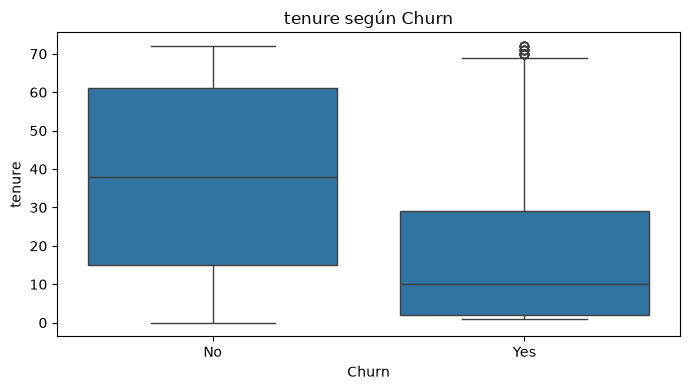

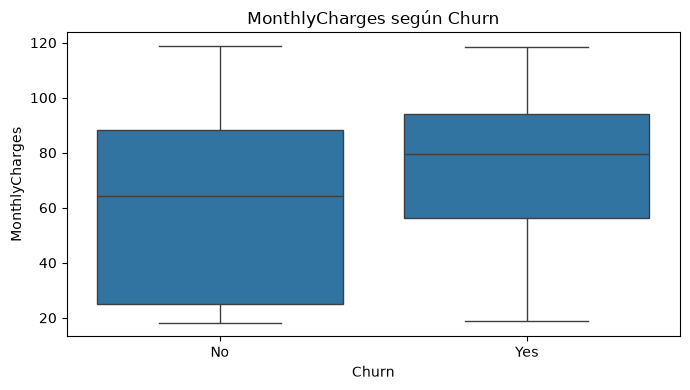

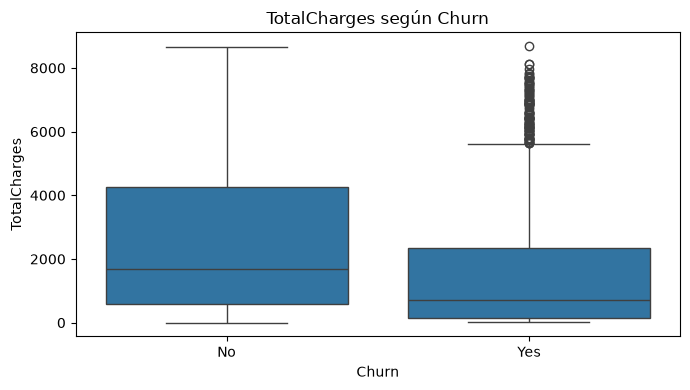

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))

    sns.boxplot(data=df, x="Churn", y=col)

    plt.title(f"{col} según Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [ ]:
df.groupby("Churn")[numeric_cols].agg(["mean", "median"]).round(2)

tenure        MonthlyCharges        TotalCharges         
        mean median           mean median         mean   median
Churn                                                          
No     37.57   38.0          61.27  64.43      2549.91  1679.52
Yes    17.98   10.0          74.44  79.65      1531.80   703.55

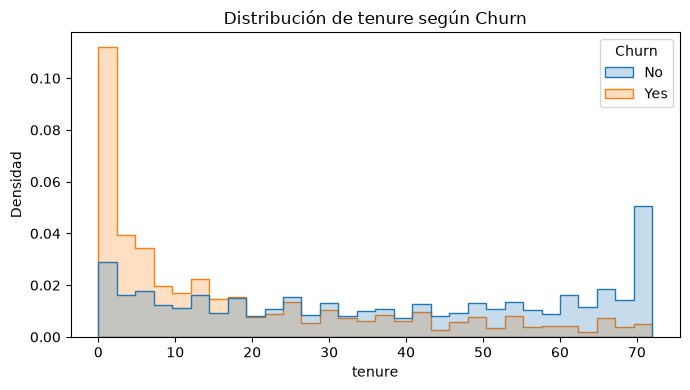

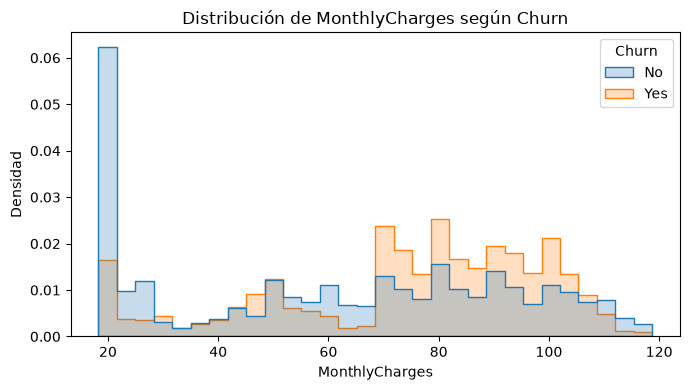

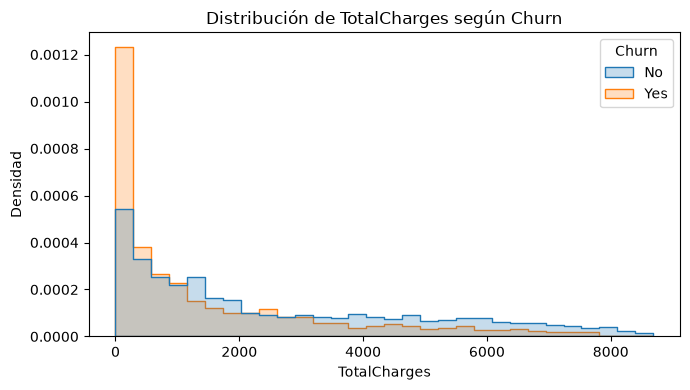

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=col,
        hue="Churn",
        bins=30,
        stat="density",
        common_norm=False,
        element="step",
    )

    plt.title(f"Distribución de {col} según Churn")
    plt.xlabel(col)
    plt.ylabel("Densidad")
    plt.tight_layout()
    plt.show()

Las variables numéricas también presentan diferencias entre los clientes que abandonan y los que permanecen.

Los clientes que hacen churn presentan una antigüedad considerablemente menor, con una mediana de `tenure` de 10 meses frente a 38 meses entre los clientes que permanecen. Por el contrario, sus cargos mensuales son superiores, con una mediana de `MonthlyCharges` de 79,65 frente a 64,43.

A pesar de presentar cargos mensuales superiores, los clientes que abandonan muestran menores `TotalCharges`. Este comportamiento es coherente con su menor antigüedad, ya que disponen de menos tiempo para acumular cargos.

Las distribuciones refuerzan estas diferencias: el churn se concentra en mayor medida entre clientes con menor antigüedad y menores cargos acumulados, mientras que sus cargos mensuales tienden a situarse en valores más elevados.

Estos resultados representan asociaciones observadas en los datos y no implican relaciones causales.

## 6. Correlación entre variables numéricas

In [90]:
numeric_corr = df[numeric_cols].corr()

numeric_corr

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


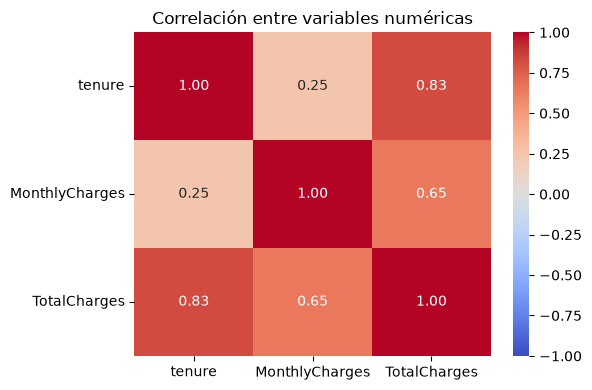

In [ ]:
plt.figure(figsize=(6, 4))

sns.heatmap(numeric_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Correlación entre variables numéricas")
plt.tight_layout()
plt.show()

La matriz de correlación muestra una relación positiva fuerte entre `tenure` y `TotalCharges` (0,83), coherente con el carácter acumulativo de los cargos totales.

También se observa una correlación positiva moderada-alta entre `MonthlyCharges` y `TotalCharges` (0,65), mientras que la relación entre `tenure` y `MonthlyCharges` es considerablemente menor (0,25).

La elevada correlación entre `tenure` y `TotalCharges` indica que ambas variables contienen información parcialmente relacionada. Esta relación deberá tenerse en cuenta especialmente al interpretar modelos lineales, aunque no se eliminará ninguna variable únicamente a partir de su correlación.

## 7. Conclusiones EDA

### 7.1 Calidad de los datos

El dataset contiene 7.043 clientes y 21 variables, sin registros duplicados. `customerID` identifica de forma única a cada cliente y será excluido posteriormente de las variables predictoras.

Se detectaron 11 valores en blanco en `TotalCharges`, todos ellos correspondientes a clientes con `tenure = 0`. La variable se convirtió a formato numérico y estos registros se trataron como cargos acumulados iguales a 0.

También se identificaron dependencias estructurales entre variables relacionadas con los servicios de Internet y telefonía, que deberán tenerse en cuenta durante el preprocesamiento.

### 7.2 Principales asociaciones con `Churn`

La variable objetivo presenta un desbalance moderado, con aproximadamente un 26,5 % de clientes que abandonan el servicio.

Entre las variables categóricas, se observan diferencias destacadas en las tasas de churn según `Contract`, `InternetService`, `PaymentMethod`, `OnlineSecurity` y `TechSupport`, entre otras. Por el contrario, variables como `gender` presentan diferencias reducidas entre categorías.

En las variables numéricas, los clientes que abandonan presentan una antigüedad considerablemente menor y cargos mensuales superiores. Sus cargos acumulados son, sin embargo, inferiores, comportamiento coherente con su menor antigüedad.

La correlación entre `tenure` y `TotalCharges` es elevada (0,83), indicando que ambas variables contienen información parcialmente relacionada.

### 7.3 Implicaciones para el modelado

El EDA muestra que existen patrones potencialmente útiles para la predicción de `Churn`, pero también identifica varios aspectos que deberán tratarse durante el preprocesamiento:

- `customerID` deberá excluirse como variable predictora.
- Las variables numéricas y categóricas requerirán transformaciones diferentes.
- `SeniorCitizen` deberá interpretarse como una característica binaria.
- Las categorías asociadas a la ausencia de servicios de Internet o telefonía deberán tratarse preservando su significado.
- El desbalance de la variable objetivo deberá considerarse al seleccionar las métricas de evaluación.
- La relación entre `tenure` y `TotalCharges` deberá tenerse en cuenta, especialmente al interpretar modelos lineales.

Las relaciones identificadas durante este análisis son asociaciones observadas en los datos y no implican causalidad.
